<a href="https://colab.research.google.com/github/pramodgurung10/AI-ML/blob/main/2438404_Pramod_Gurung_LanguageTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##SMS Spam vs Ham Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


All libraries imported successfully!


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# contractions: expands short forms like "don't" → "do not"
# wordcloud   : for visualising frequent words
!pip install contractions wordcloud -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.1 MB/s eta 0:00:00


In [4]:
df = pd.read_csv('/content/drive/MyDrive/ConceptAI/9.Spam vs Ham Sms Dataset/spamvsham.csv', encoding='latin1')

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
df.columns = ['label', 'message']

# Encode string labels to integers
# ham  → 0  (legitimate message — negative class)
# spam → 1  (spam message     — positive class)
# Keras models require numeric labels; binary_crossentropy expects 0 or 1.
df['label'] = df['label'].map({'ham': 0, 'spam': 1})



In [7]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print("Dataset loaded successfully!")
print(f"Total samples : {len(df)}")
print()
print("Class Distribution (raw counts):")
print(df['label'].value_counts().rename(index={0: 'ham (0)', 1: 'spam (1)'}))
print()
print("Class Distribution (percentage):")
print(df['label'].value_counts(normalize=True).mul(100).round(1)
      .rename(index={0: 'ham (0)', 1: 'spam (1)'}).astype(str) + '%')

Dataset loaded successfully!
Total samples : 5572

Class Distribution (raw counts):
label
ham (0)     4825
spam (1)     747
Name: count, dtype: int64

Class Distribution (percentage):
label
ham (0)     86.6%
spam (1)    13.4%
Name: proportion, dtype: object


In [9]:
# ── Split into train / val / test (70 / 10 / 20) ─────────────────────────────

# Step 1: Split 80% train+val  vs  20% test
# stratify ensures ham/spam ratio is preserved in every split
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['label']
)



train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,
    random_state=42,
    stratify=train_val_df['label']
)

print(f"Training samples   : {len(train_df)}  ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation samples : {len(val_df)}   ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test samples       : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)")
print()
# print("Spam ratio check (must be ~13% in all splits):")
# print(f"  Train : {train_df['label'].mean()*100:.1f}% spam")
# print(f"  Val   : {val_df['label'].mean()*100:.1f}% spam")
# print(f"  Test  : {test_df['label'].mean()*100:.1f}% spam")

Training samples   : 3899  (70.0%)
Validation samples : 558   (10.0%)
Test samples       : 1115  (20.0%)



##Data Exploration and Visualization

In [10]:
# Basic info on training set
print("Training Data Info")
print(train_df.info())
print()
print("Missing Values")
print(train_df.isnull().sum())

Training Data Info
<class 'pandas.core.frame.DataFrame'>
Index: 3899 entries, 2776 to 781
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    3899 non-null   int64 
 1   message  3899 non-null   object
dtypes: int64(1), object(1)
memory usage: 91.4+ KB
None

Missing Values
label      0
message    0
dtype: int64


Label Distribution in Training Set
label
ham     3376
spam     523
Name: count, dtype: int64


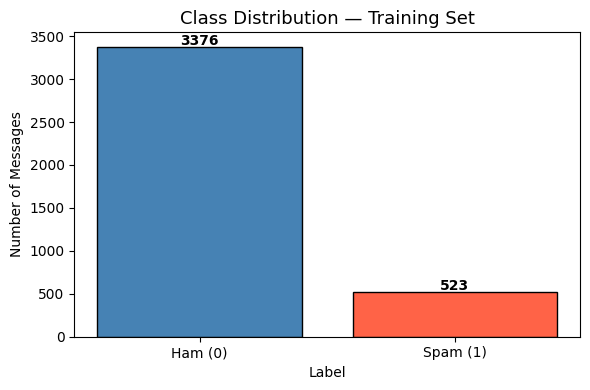


NOTE: The dataset is heavily imbalanced (~87% ham, ~13% spam).
We will address this using class_weight during model training.


In [11]:
# Class Distribution Bar Chart
# IMPORTANT: This visualisation is critical for understanding class imbalance.
# The dataset has ~87% ham and ~13% spam — we must address this before training.

print("Label Distribution in Training Set")
print(train_df['label'].value_counts().rename(index={0: 'ham', 1: 'spam'}))

labels = ['Ham (0)', 'Spam (1)']
counts = train_df['label'].value_counts().sort_index().values

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Class Distribution — Training Set', fontsize=13)
plt.xlabel('Label')
plt.ylabel('Number of Messages')
for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("NOTE: The dataset is heavily imbalanced (~87% ham, ~13% spam).")
print("We will address this using class_weight during model training.")

Message Length Statistics (Word Count — Before Cleaning)
count    3899.000000
mean       15.404463
std        11.062177
min         1.000000
25%         7.000000
50%        12.000000
75%        22.000000
max       162.000000
Name: msg_length, dtype: float64


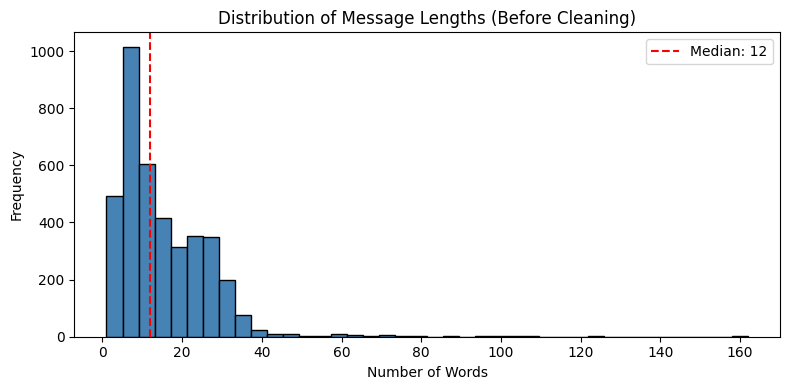

In [12]:
# SMS Message Length Analysis (before cleaning)
# This directly determines what MAX_LEN we should use for padding.

train_df['msg_length'] = train_df['message'].apply(lambda x: len(str(x).split()))

print("Message Length Statistics (Word Count — Before Cleaning)")
print(train_df['msg_length'].describe())

plt.figure(figsize=(8, 4))
plt.hist(train_df['msg_length'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Message Lengths (Before Cleaning)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(train_df['msg_length'].median(), color='red',
            linestyle='dashed', label=f"Median: {train_df['msg_length'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

##Text Preprocessong

In [13]:
import contractions

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Full SMS cleaning pipeline.
    Steps:
        1. Lowercase
        2. Expand contractions   (don't → do not)
        3. Remove URLs
        4. Remove special characters and punctuation
        5. Remove numbers
        6. Remove extra whitespace
        7. Remove stopwords and lemmatize
    Note: No HTML removal — SMS messages contain no HTML tags.
    """
    # Step 1: Lowercase
    text = str(text).lower()

    # Step 2: Expand contractions (e.g. "won't" → "will not")
    text = contractions.fix(text)

    # Step 3: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Step 4: Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text,)

    # Step 5: Remove numbers
    text = re.sub(r'\d+', '', text)

    # Step 6: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 7: Remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)


In [14]:
# Test the pipeline on one spam and one ham example
sample_spam = train_df[train_df['label'] == 1]['message'].iloc[0]
sample_ham  = train_df[train_df['label'] == 0]['message'].iloc[0]

print("SPAM — BEFORE:", sample_spam)
print("SPAM — AFTER :", preprocess_text(sample_spam))
print()
print("HAM  — BEFORE:", sample_ham)
print("HAM  — AFTER :", preprocess_text(sample_ham))

SPAM — BEFORE: Bored of speed dating? Try SPEEDCHAT, txt SPEEDCHAT to 80155, if you don't like em txt SWAP and get a new chatter! Chat80155 POBox36504W45WQ 150p/msg rcd 16
SPAM — AFTER : bored speed dating try speedchat txt speedchat like txt swap get new chatter chat poboxwwq pmessage rcd

HAM  — BEFORE: Send me your id and password
HAM  — AFTER : send id password


In [15]:
# Apply cleaning to all three splits
print("Cleaning training data...")
train_df['cleaned_message'] = train_df['message'].apply(preprocess_text)

print("Cleaning validation data...")
val_df['cleaned_message'] = val_df['message'].apply(preprocess_text)

print("Cleaning test data...")
test_df['cleaned_message'] = test_df['message'].apply(preprocess_text)

print("\nDone! Cleaned text added to 'cleaned_message' column.")

Cleaning training data...
Cleaning validation data...
Cleaning test data...

Done! Cleaned text added to 'cleaned_message' column.


In [16]:
# Drop rows with missing labels or empty messages after cleaning
train_df = train_df.dropna(subset=['label'])
val_df   = val_df.dropna(subset=['label'])
test_df  = test_df.dropna(subset=['label'])

train_df = train_df[train_df['cleaned_message'].str.strip() != '']
val_df   = val_df[val_df['cleaned_message'].str.strip() != '']
test_df  = test_df[test_df['cleaned_message'].str.strip() != '']

print(f"Training samples after cleaning   : {len(train_df)}")
print(f"Validation samples after cleaning  : {len(val_df)}")
print(f"Test samples after cleaning        : {len(test_df)}")

Training samples after cleaning   : 3892
Validation samples after cleaning  : 558
Test samples after cleaning        : 1112


In [17]:
# Before vs After comparison table
comparison_df = pd.DataFrame({
    'Original Message' : train_df['message'].str[:60].values[:5],
    'Cleaned Message'  : train_df['cleaned_message'].str[:60].values[:5],
    'Label'            : train_df['label'].map({0: 'ham', 1: 'spam'}).values[:5]
})
comparison_df

,Original Message,Cleaned Message,Label
0,Send me your id and password,send id password,ham
1,Yeah jay's sort of a fucking retard,yeah jay sort fucking retard,ham
2,But really quite funny lor wat... Then u shd h...,really quite funny lor wat shd haf run shorter...,ham
3,Surly ill give it to you:-) while coming to re...,surly ill give coming review,ham
4,Not sure I have the stomach for it ...,sure stomach,ham


##Text Visualisation

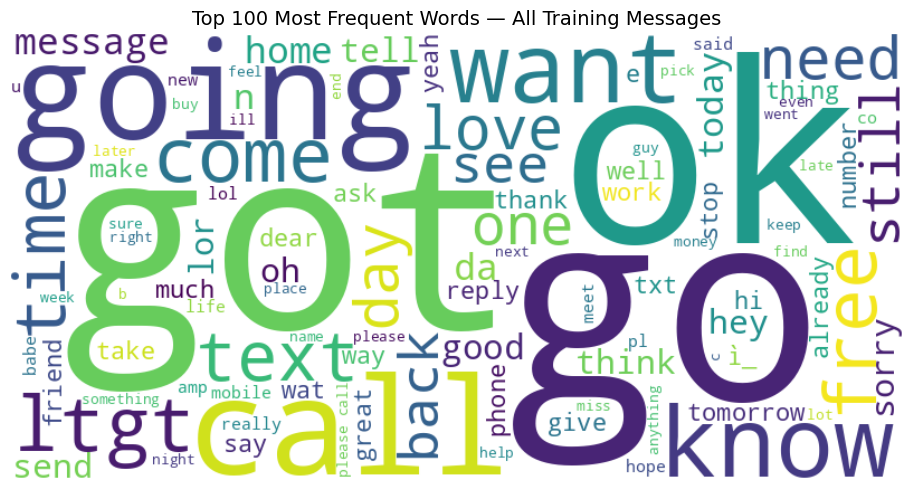

In [18]:
# overall Word Cloud
all_words = ' '.join(train_df['cleaned_message'])

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words — All Training Messages', fontsize=14)
plt.tight_layout()
plt.show()

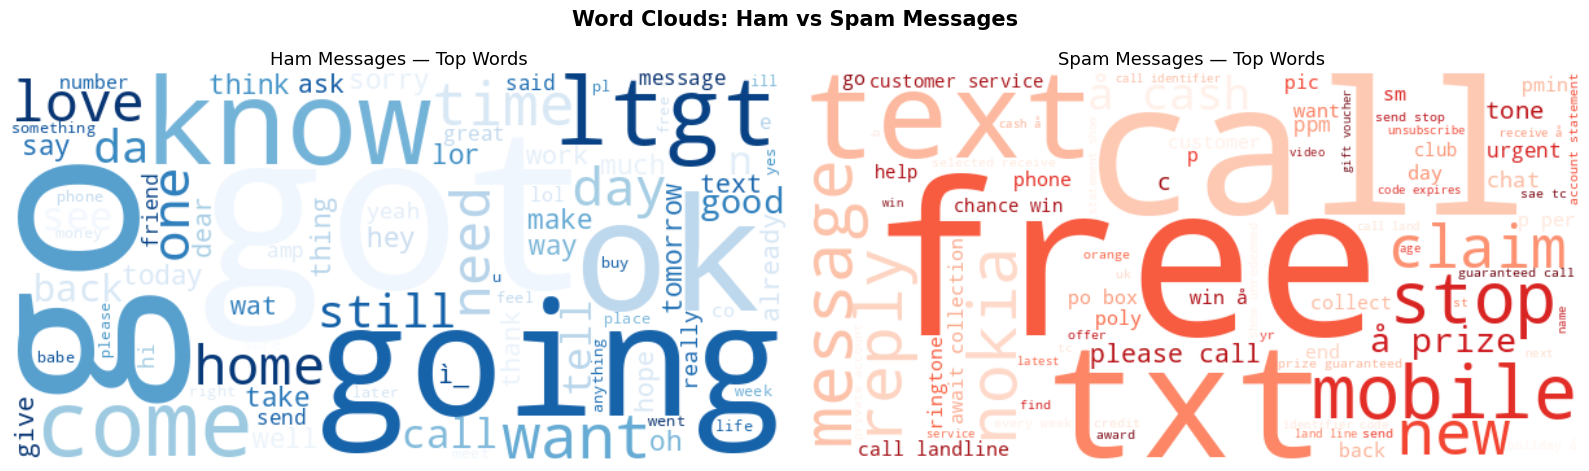

In [19]:
# Ham vs Spam Word Clouds
# This visualisation reveals which words are distinctive for each class.

ham_words  = ' '.join(train_df[train_df['label'] == 0]['cleaned_message'])
spam_words = ' '.join(train_df[train_df['label'] == 1]['cleaned_message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_ham = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='Blues').generate(ham_words)
axes[0].imshow(wc_ham, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Ham Messages — Top Words', fontsize=13)

wc_spam = WordCloud(width=600, height=300, background_color='white',
                    max_words=80, colormap='Reds').generate(spam_words)
axes[1].imshow(wc_spam, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Spam Messages — Top Words', fontsize=13)

plt.suptitle('Word Clouds: Ham vs Spam Messages', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

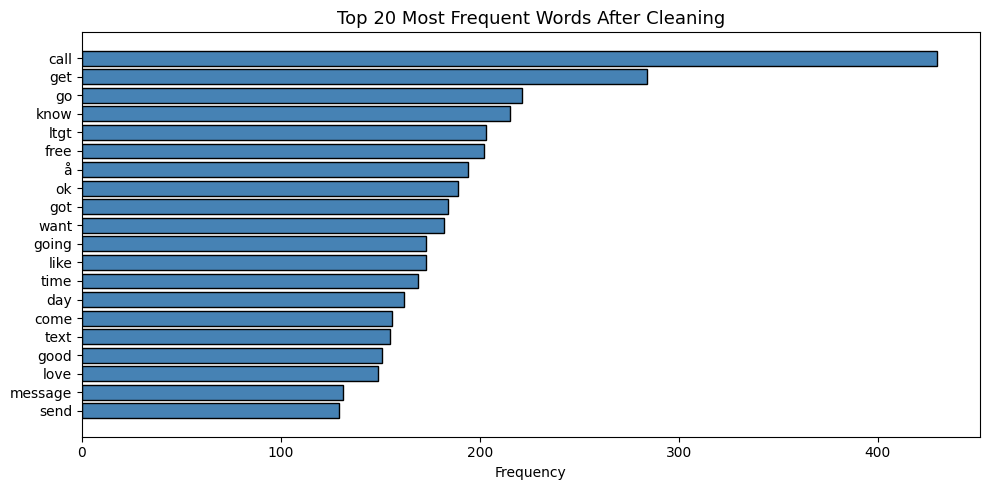

In [20]:
# Top 20 Most Frequent Words
all_tokens = ' '.join(train_df['cleaned_message']).split()
word_freq  = Counter(all_tokens)
top_20     = word_freq.most_common(20)

words  = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words After Cleaning', fontsize=13)
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

##Compute Class Weights

**Why class weights?**  
The dataset has ~87% ham and ~13% spam. Without correction, a model could achieve 87%
accuracy by predicting *everything* as ham — without learning any real patterns.
compute_class_weight('balanced') assigns a higher penalty to mistakes on the minority
class (spam), forcing the model to take it seriously.
- **Ham weight  ≈ 0.57** — majority class, penalised less
- **Spam weight ≈ 3.72** — minority class, penalised more

These weights are passed to every model.fit() call via class_weight=class_weight_dict.

In [21]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['label'].values
)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:")
print(f"  Ham  (0) : {class_weight_dict[0]:.4f}")
print(f"  Spam (1) : {class_weight_dict[1]:.4f}")
print()
print("Interpretation:")
print("  Spam errors are penalised ~{:.1f}x more than ham errors.".format(
      class_weight_dict[1] / class_weight_dict[0]))

Class Weights:
  Ham  (0) : 0.5776
  Spam (1) : 3.7208

Interpretation:
  Spam errors are penalised ~6.4x more than ham errors.


##Tokenisation and Sequence Padding

In [22]:
# ── Prepare features and labels ──────────────────────────────────────────────
X_train = train_df['cleaned_message'].values
y_train = train_df['label'].values

X_val   = val_df['cleaned_message'].values
y_val   = val_df['label'].values

X_test  = test_df['cleaned_message'].values
y_test  = test_df['label'].values

print(f"X_train shape: {X_train.shape}  |  y_train shape: {y_train.shape}")
print(f"X_val shape  : {X_val.shape}    |  y_val shape  : {y_val.shape}")
print(f"X_test shape : {X_test.shape}   |  y_test shape : {y_test.shape}")

X_train shape: (3892,)  |  y_train shape: (3892,)
X_val shape  : (558,)    |  y_val shape  : (558,)
X_test shape : (1112,)   |  y_test shape : (1112,)


In [23]:
# Tokenisation
# VOCAB_SIZE = 5000: appropriate for ~3900 short SMS training messages.
# oov_token='<OOV>': maps unseen words (in val/test) to a single token
#                    rather than dropping them silently.
# IMPORTANT: fit ONLY on training data — never on val or test.
#            Fitting on val/test would be data leakage.

VOCAB_SIZE = 5000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # fit on training data ONLY

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

actual_vocab = len(tokenizer.word_index) + 1
print(f"Vocabulary learned from training data : {actual_vocab}")
print(f"Vocabulary used (capped at)           : {VOCAB_SIZE}")
print()
print("Example: Text → Sequence")
print(f"Text    : {X_train[0]}")
print(f"Sequence: {X_train_seq[0]}")

Vocabulary learned from training data : 6303
Vocabulary used (capped at)           : 5000

Example: Text → Sequence
Text    : send id password
Sequence: [21, 493, 874]


Min length    : 1
Max length    : 70
Mean length   : 8.3
Median length : 7.0
95th Pctile   : 19


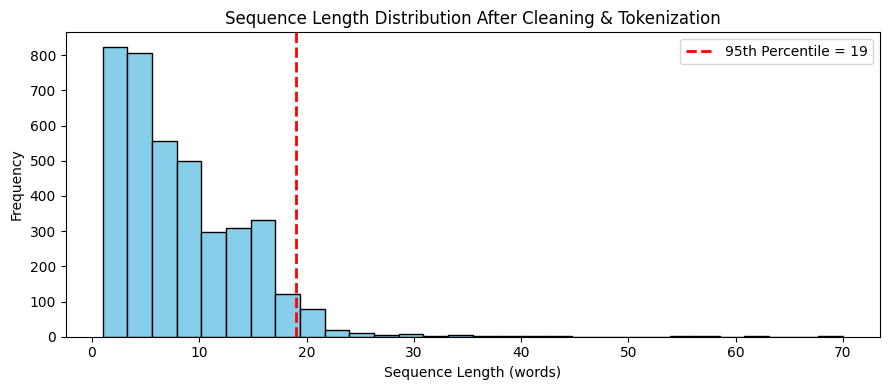

In [24]:
#  Sequence Length Analysis → choose MAX_LEN
# SMS messages are very short (typically 5–30 words after cleaning).
# Using the 95th percentile avoids padding most sequences with excessive zeros,
# which wastes computation and can dilute the learned signal.

seq_lengths = [len(seq) for seq in X_train_seq]

print(f"Min length    : {np.min(seq_lengths)}")
print(f"Max length    : {np.max(seq_lengths)}")
print(f"Mean length   : {np.mean(seq_lengths):.1f}")
print(f"Median length : {np.median(seq_lengths):.1f}")
print(f"95th Pctile   : {np.percentile(seq_lengths, 95):.0f}")

plt.figure(figsize=(9, 4))
plt.hist(seq_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title('Sequence Length Distribution After Cleaning & Tokenization')
plt.xlabel('Sequence Length (words)')
plt.ylabel('Frequency')
plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='dashed',
            linewidth=2, label=f"95th Percentile = {int(np.percentile(seq_lengths, 95))}")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
#  Padding
# MAX_LEN is set to the 95th percentile of training sequence lengths.
# For SMS data this will be ~30-40 tokens (vs 301 for movie reviews).
# padding='post'    → zeros added at END  (standard for RNN/LSTM)
# truncating='post' → long sequences cut from END

MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f"MAX_LEN set to: {MAX_LEN} tokens (95th percentile of training lengths)")
print()

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_val_pad shape   : {X_val_pad.shape}")
print(f"X_test_pad shape  : {X_test_pad.shape}")

MAX_LEN set to: 19 tokens (95th percentile of training lengths)

X_train_pad shape : (3892, 19)
X_val_pad shape   : (558, 19)
X_test_pad shape  : (1112, 19)


In [26]:
# Padding example
print("Padding Example")
print(f"Original sequence length : {len(X_train_seq[0])}")
print(f"After padding            : {len(X_train_pad[0])}")
print(f"Padded sequence          : {X_train_pad[0]}")
# print("(Trailing zeros are padding tokens)")

Padding Example
Original sequence length : 3
After padding            : 19
Padded sequence          : [ 21 493 874   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0]


SUMMARY — TEXT PREPROCESSING

Dataset         : SMS Spam Collection v.1 (Binary Classification)
Train samples   : 3892
Val samples     : 558
Test samples    : 1112

Cleaning Steps Applied:
  1. Lowercasing
  2. Contraction expansion
  3. URL removal
  4. Special character & punctuation removal
  5. Number removal
  6. Stopword removal
  7. Lemmatization
  Note: No HTML removal — SMS messages contain no HTML tags

Tokenizer       : Keras Tokenizer (vocab=5000, oov='<OOV>')
Padding         : Post-padding to MAX_LEN=19 (95th percentile)
Class Weights   : Ham=0.58, Spam=3.72

##Build and Train Models

In [27]:
import itertools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Model libraries imported successfully!")

Model libraries imported successfully!


In [28]:
# Reusable confusion matrix plotting function
# Updated to use Ham/Spam class names instead of Negative/Positive

def plot_confusion_matrix(cm, title, classes=['Ham', 'Spam']):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

print("plot_confusion_matrix() defined!")

plot_confusion_matrix() defined!


##Model 1 - Simple RNN with Trainable Embeddings

**Architecture choices for SMS data:**
- EMBEDDING_DIM = 64 : SMS messages are short and vocabulary is small (~5000).
  A 256-dim embedding (used for movie reviews) would be over-parameterised here.
- RNN units 64 → 32: Smaller hidden state is sufficient for short sequences.
- batch_size = 32: With only ~3900 training samples, smaller batches give more
  gradient updates per epoch and help the model converge on limited data

In [29]:

rnn_model = Sequential(name='Simple_RNN_Model')

rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=64))


rnn_model.add(SimpleRNN(units=64,
                         return_sequences=True,))

rnn_model.add(Dropout(0.3))                          # dropout between layers

rnn_model.add(SimpleRNN(units=32,
                         return_sequences=False,
                       ))

rnn_model.add(Dropout(0.3))                          # dropout before output
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "Simple_RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 19, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 19, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,393 (1.26 MB)

 Trainable params: 331,393 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
rnn_model.compile(
    loss='binary_crossentropy',   # standard for binary classification (0/1)
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)


In [31]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)
checkpoint_rnn = ModelCheckpoint(
    'best_rnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training Model 1 (Simple RNN)")
print("NOTE: class_weight addresses the 87/13 ham/spam imbalance.")

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,       # penalises spam errors more heavily
    callbacks=[early_stop, checkpoint_rnn],
    verbose=1
)

Training Model 1 (Simple RNN)
NOTE: class_weight addresses the 87/13 ham/spam imbalance.
Epoch 1/15
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6931 - loss: 0.5679
Epoch 1: val_accuracy improved from None to 0.96237, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.8222 - loss: 0.4203 - val_accuracy: 0.9624 - val_loss: 0.1207
Epoch 2/15
120/122 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9757 - loss: 0.1220
Epoch 2: val_accuracy did not improve from 0.96237
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9720 - loss: 0.1302 - val_accuracy: 0.9283 - val_loss: 0.2061
Epoch 3/15
117/122 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9908 - loss: 0.0629
Epoch 3: val_accuracy improved from 0.96237 to 0.96595, saving model to best_rnn_model.keras

Epoch 3: finished saving model to best_rnn_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9908 - loss: 0.

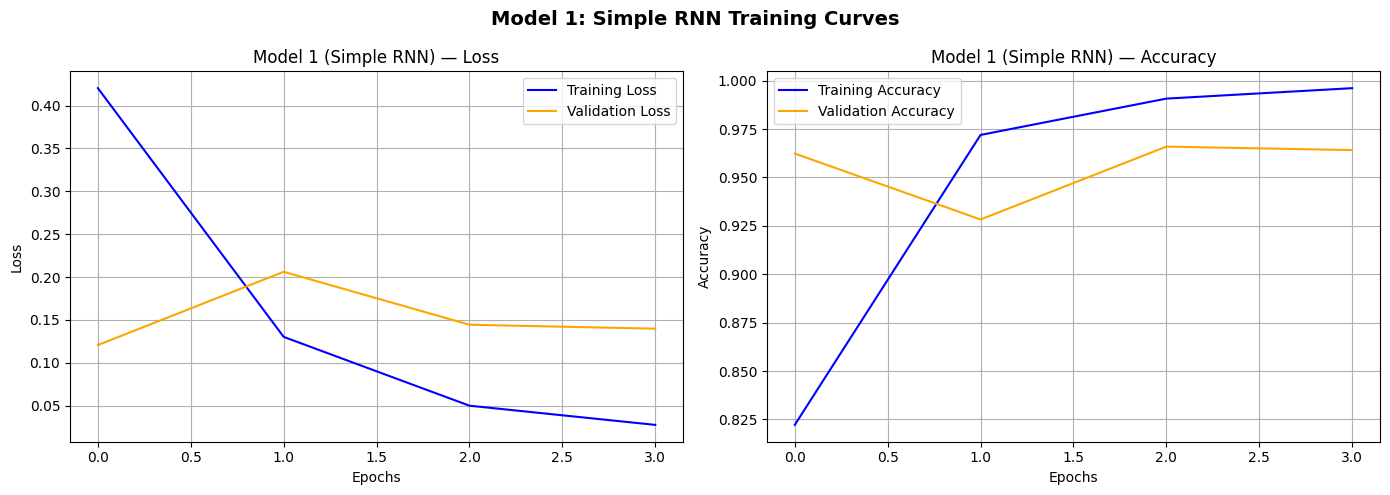

In [32]:
# Plot training curves — Model 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_rnn.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model 1 (Simple RNN) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_rnn.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_rnn.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Model 1 (Simple RNN) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model 1: Simple RNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
print("MODEL 1 EVALUATION — Simple RNN")

y_pred_rnn_prob = rnn_model.predict(X_test_pad, verbose=0)
y_pred_rnn      = (y_pred_rnn_prob > 0.5).astype(int).flatten()

acc_rnn = accuracy_score(y_test, y_pred_rnn)
print(f"\nTest Accuracy: {acc_rnn:.4f}")
print()
print("Confusion Matrix:")
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
print(cm_rnn)
print()
print("Classification Report:")
# target_names updated to Ham/Spam
print(classification_report(y_test, y_pred_rnn, target_names=['Ham', 'Spam']))
print()
print("NOTE: For imbalanced spam data, focus on Spam F1-score,")
print("not just overall accuracy. A model predicting all-ham")
print(f"would score {(y_test==0).mean()*100:.1f}% accuracy with zero spam recall.")

MODEL 1 EVALUATION — Simple RNN

Test Accuracy: 0.9766

Confusion Matrix:
[[954   9]
 [ 17 132]]

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       963
        Spam       0.94      0.89      0.91       149

    accuracy                           0.98      1112
   macro avg       0.96      0.94      0.95      1112
weighted avg       0.98      0.98      0.98      1112


NOTE: For imbalanced spam data, focus on Spam F1-score,
not just overall accuracy. A model predicting all-ham
would score 86.6% accuracy with zero spam recall.


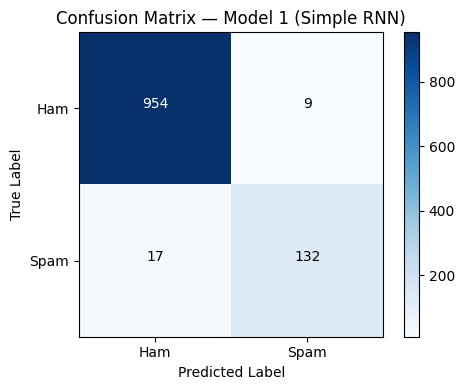

In [34]:
plot_confusion_matrix(cm_rnn, 'Confusion Matrix — Model 1 (Simple RNN)')

##Model 2 - LSTM with Trainable Embedding

**Why LSTM over Simple RNN?**  
Simple RNNs suffer from the **vanishing gradient problem** — gradients shrink as they
propagate back through time steps, making it hard to learn dependencies between distant
words. LSTM's gating mechanism (input, forget, output gates) allows it to selectively
remember or forget information, enabling better capture of long-range context.
Even for short SMS messages, LSTM typically outperforms SimpleRNN.

In [35]:
# ── Model 2: LSTM with Trainable Embedding ───────────────────────────────────
lstm_model = Sequential(name='LSTM_Model')

lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=64))
lstm_model.add(LSTM(units=64, return_sequences=True))    # first LSTM layer
lstm_model.add(Dropout(0.3))
lstm_model.add(LSTM(units=32, return_sequences=False))   # second LSTM layer
lstm_model.add(Dropout(0.4))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 19, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 19, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,473 (1.39 MB)

 Trainable params: 365,473 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)


In [37]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

checkpoint_lstm = ModelCheckpoint(
    'best_lstm_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max', verbose=1)

print("Training Model 2 (LSTM)")
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,   # same imbalance correction as Model 1
    callbacks=[early_stop, checkpoint_lstm],
    verbose=1
)

Training Model 2 (LSTM)
Epoch 1/15
119/122 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7183 - loss: 0.6806
Epoch 1: val_accuracy improved from None to 0.85663, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8279 - loss: 0.6484 - val_accuracy: 0.8566 - val_loss: 0.3893
Epoch 2/15
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8757 - loss: 0.4275
Epoch 2: val_accuracy improved from 0.85663 to 0.91577, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8777 - loss: 0.3555 - val_accuracy: 0.9158 - val_loss: 0.2008
Epoch 3/15
119/122 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9689 - loss: 0.1458
Epoch 3: val_accuracy improved from 0.91577 to 0.96595, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 9

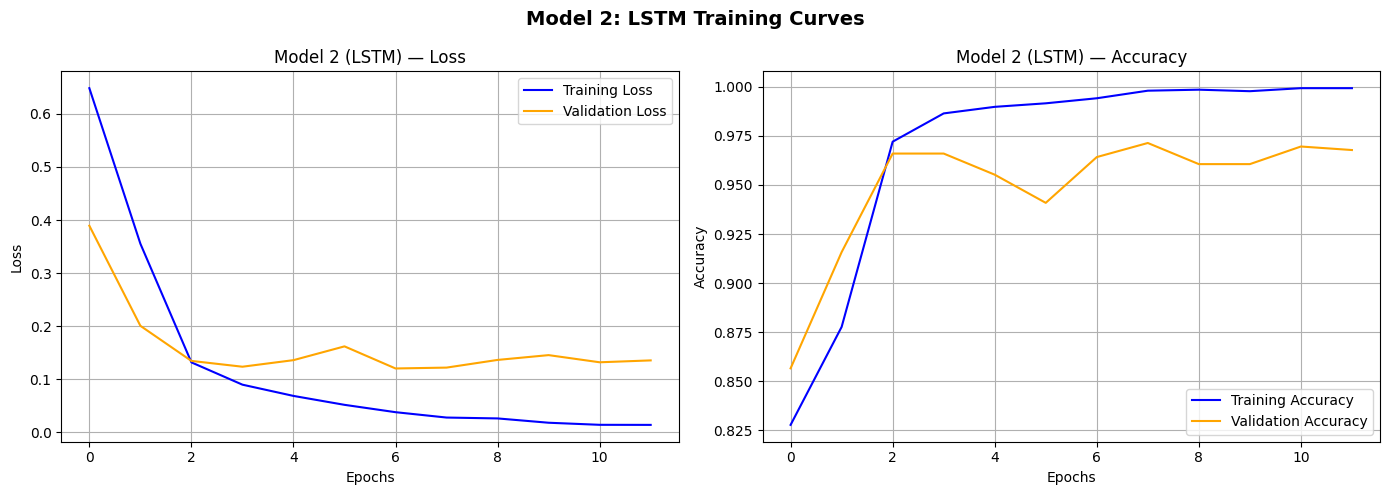

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_lstm.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model 2 (LSTM) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history_lstm.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Model 2 (LSTM) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)
plt.suptitle('Model 2: LSTM Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
print("MODEL 2 EVALUATION — LSTM")
y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm      = (y_pred_lstm_prob > 0.5).astype(int).flatten()
acc_lstm = accuracy_score(y_test, y_pred_lstm)
print(f"\nTest Accuracy: {acc_lstm:.4f}")
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print("\nConfusion Matrix:")
print(cm_lstm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Ham', 'Spam']))

MODEL 2 EVALUATION — LSTM

Test Accuracy: 0.9721

Confusion Matrix:
[[951  12]
 [ 19 130]]

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       963
        Spam       0.92      0.87      0.89       149

    accuracy                           0.97      1112
   macro avg       0.95      0.93      0.94      1112
weighted avg       0.97      0.97      0.97      1112



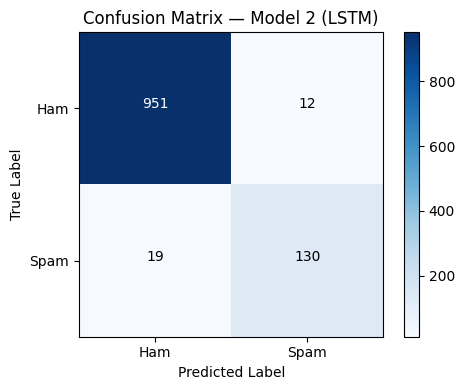

In [40]:
plot_confusion_matrix(cm_lstm, 'Confusion Matrix — Model 2 (LSTM)')

##Model 3 - LSTM with the Pre-trained Clove Twitter Embeddigs

In [41]:
# Install gensim for downloading pre-trained embeddings
# Note: downgrading numpy is sometimes needed for gensim compatibility in Colab
!pip install numpy==1.23.5 -q
!pip install gensim -q
print("gensim installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 93.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.0 MB/s eta 0:00:00
gensim installed!


In [42]:
import gensim.downloader as api

embedding_model = api.load('glove-twitter-50')
GLOVE_DIM = 50

print(f"GloVe loaded! Dimension: {GLOVE_DIM}")
print(f"Words in vocabulary: {len(embedding_model)}")

[==================================================] 100.0% 199.5/199.5MB downloaded
GloVe loaded! Dimension: 50
Words in vocabulary: 1193514


In [43]:
# Build Embedding Matrix


word_index = tokenizer.word_index
vocab_size  = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

found     = 0
not_found = 0

for word, index in word_index.items():
    if index < vocab_size:
        if word in embedding_model:
            embedding_matrix[index] = embedding_model[word]
            found += 1
        else:
            not_found += 1

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Words found in GloVe   : {found}")
print(f"Words NOT found        : {not_found}")
print(f"Coverage               : {found / (found + not_found) * 100:.1f}%")
print()


Embedding matrix shape : (5000, 50)
Words found in GloVe   : 4062
Words NOT found        : 937
Coverage               : 81.3%



In [44]:
#  Model 3: LSTM + GloVe Twitter
lstm_glove_model = Sequential(name='LSTM_GloVe_Twitter_Model')

# Embedding layer with pre-trained weights, frozen (trainable=False)
lstm_glove_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    trainable=False           # freeze: preserve Twitter GloVe knowledge
))

lstm_glove_model.add(LSTM(units=64, return_sequences=True))
lstm_glove_model.add(Dropout(0.3))
lstm_glove_model.add(LSTM(units=32, return_sequences=False))
lstm_glove_model.add(Dropout(0.5))
lstm_glove_model.add(Dense(1, activation='sigmoid'))

lstm_glove_model.build(input_shape=(None, MAX_LEN))
lstm_glove_model.summary()

Model: "LSTM_GloVe_Twitter_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 19, 50)         │       250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 19, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,889 (1.11 MB)

 Trainable params: 41,889 (163.63 KB)

 Non-trainable params: 250,000 (976.56 KB)

In [45]:
lstm_glove_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)


In [46]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint_glove = ModelCheckpoint(
    'best_lstm_glove_model.keras', monitor='val_accuracy',
    save_best_only=True, mode='max', verbose=1)

print("Training Model 3 (LSTM + GloVe Twitter)...")
history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,   # same imbalance correction
    callbacks=[early_stop, checkpoint_glove],
    verbose=1
)

Training Model 3 (LSTM + GloVe Twitter)...
Epoch 1/15
117/122 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6947 - loss: 0.4718
Epoch 1: val_accuracy improved from None to 0.95699, saving model to best_lstm_glove_model.keras

Epoch 1: finished saving model to best_lstm_glove_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8420 - loss: 0.3185 - val_accuracy: 0.9570 - val_loss: 0.1863
Epoch 2/15
120/122 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9480 - loss: 0.1747
Epoch 2: val_accuracy did not improve from 0.95699
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9468 - loss: 0.1634 - val_accuracy: 0.9498 - val_loss: 0.1624
Epoch 3/15
119/122 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9536 - loss: 0.1372
Epoch 3: val_accuracy did not improve from 0.95699
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9530 - loss: 0.1385 - val_accuracy: 0.9552 - val_loss: 0.1299
Epoch 4/15
117/122 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9661 - loss: 0.11

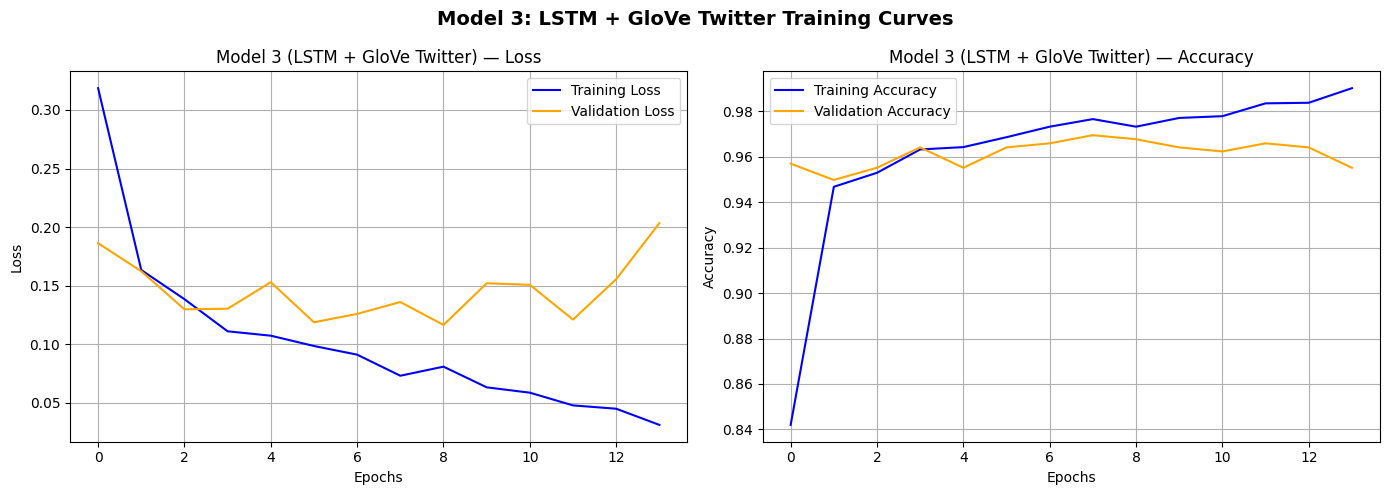

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_glove.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_glove.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model 3 (LSTM + GloVe Twitter) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history_glove.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_glove.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Model 3 (LSTM + GloVe Twitter) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)
plt.suptitle('Model 3: LSTM + GloVe Twitter Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
print("MODEL 3 EVALUATION — LSTM + GloVe Twitter")
y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()
acc_glove = accuracy_score(y_test, y_pred_glove)
print(f"\nTest Accuracy: {acc_glove:.4f}")
cm_glove = confusion_matrix(y_test, y_pred_glove)
print("\nConfusion Matrix:")
print(cm_glove)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_glove, target_names=['Ham', 'Spam']))

MODEL 3 EVALUATION — LSTM + GloVe Twitter

Test Accuracy: 0.9667

Confusion Matrix:
[[938  25]
 [ 12 137]]

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98       963
        Spam       0.85      0.92      0.88       149

    accuracy                           0.97      1112
   macro avg       0.92      0.95      0.93      1112
weighted avg       0.97      0.97      0.97      1112



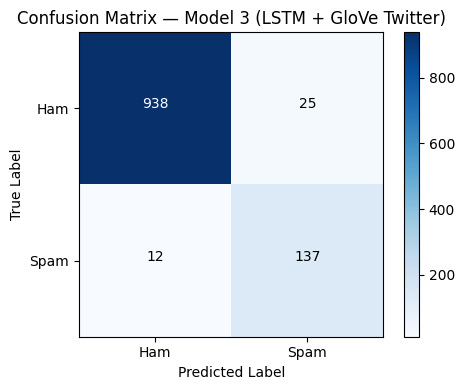

In [49]:
plot_confusion_matrix(cm_glove, 'Confusion Matrix — Model 3 (LSTM + GloVe Twitter)')

##Model Comparison

In [50]:
results_df = pd.DataFrame({
    'Model'        : ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe Twitter'],
    'Embedding'    : ['Trainable (64-dim)', 'Trainable (64-dim)', 'Frozen GloVe Twitter (25-dim)'],
    'Test Accuracy': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}']
})
print("MODEL COMPARISON — TEST ACCURACY")
print(results_df.to_string(index=False))

MODEL COMPARISON — TEST ACCURACY
                        Model                     Embedding Test Accuracy
          Model 1: Simple RNN            Trainable (64-dim)        0.9766
                Model 2: LSTM            Trainable (64-dim)        0.9721
Model 3: LSTM + GloVe Twitter Frozen GloVe Twitter (25-dim)        0.9667


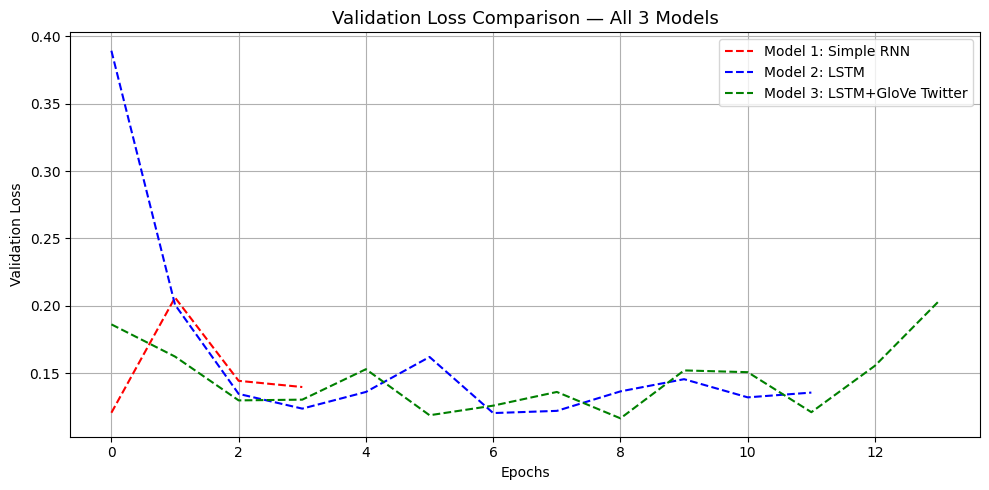

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_loss'],   label='Model 1: Simple RNN',          color='red',   linestyle='--')
plt.plot(history_lstm.history['val_loss'],  label='Model 2: LSTM',                color='blue',  linestyle='--')
plt.plot(history_glove.history['val_loss'], label='Model 3: LSTM+GloVe Twitter',  color='green', linestyle='--')
plt.title('Validation Loss Comparison — All 3 Models', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

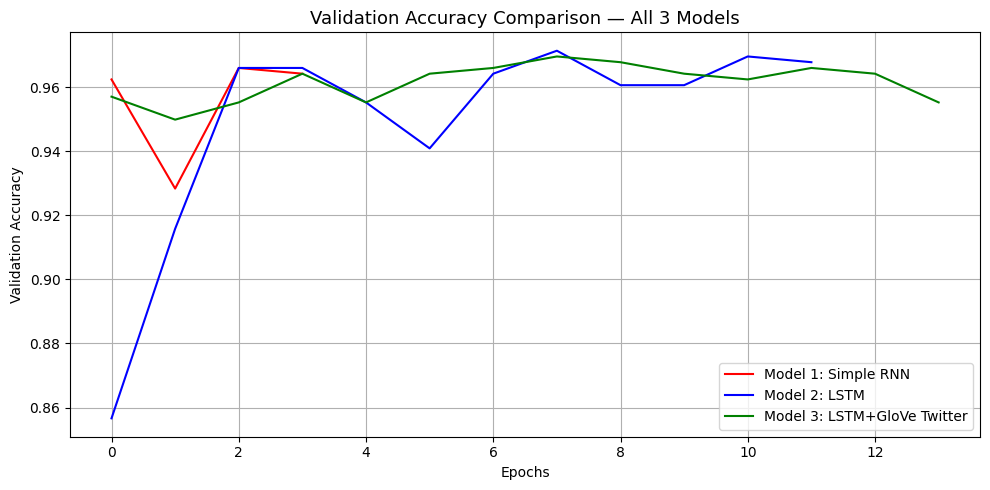

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],   label='Model 1: Simple RNN',         color='red')
plt.plot(history_lstm.history['val_accuracy'],  label='Model 2: LSTM',               color='blue')
plt.plot(history_glove.history['val_accuracy'], label='Model 3: LSTM+GloVe Twitter', color='green')
plt.title('Validation Accuracy Comparison — All 3 Models', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

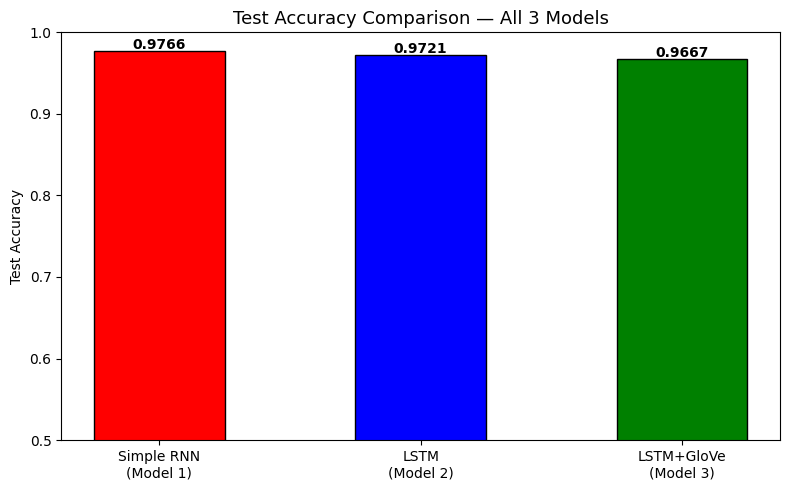

In [53]:
model_names = ['Simple RNN\n(Model 1)', 'LSTM\n(Model 2)', 'LSTM+GloVe\n(Model 3)']
accuracies  = [acc_rnn, acc_lstm, acc_glove]
colors      = ['red', 'blue', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
plt.title('Test Accuracy Comparison — All 3 Models', fontsize=13)
plt.ylabel('Test Accuracy')
plt.ylim(0.5, 1.0)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
print("=" * 60)
print(" UMMARY — MODEL BUILDING AND TRAINING")
print("=" * 60)
print()
print("Model 1 — Simple RNN")
print(f"  Embedding : Trainable (64-dim)")
print(f"  Test Acc  : {acc_rnn:.4f}")
print()
print("Model 2 — LSTM")
print(f"  Embedding : Trainable (64-dim)")
print(f"  Test Acc  : {acc_lstm:.4f}")
print()
print("Model 3 — LSTM + GloVe Twitter")
print(f"  Embedding : Frozen GloVe Twitter (50-dim, pre-trained)")
print(f"  Test Acc  : {acc_glove:.4f}")
print()
print("Common Settings:")
print("  Loss         : Binary Cross-Entropy")
print("  Optimizer    : Adam")
print("  Batch Size   : 32  (tuned for small dataset)")
print("  Class Weight : Ham=~0.57, Spam=~3.72  (imbalance correction)")
print("  EarlyStopping: patience=3")
print()


 UMMARY — MODEL BUILDING AND TRAINING

Model 1 — Simple RNN
  Embedding : Trainable (64-dim)
  Test Acc  : 0.9766

Model 2 — LSTM
  Embedding : Trainable (64-dim)
  Test Acc  : 0.9721

Model 3 — LSTM + GloVe Twitter
  Embedding : Frozen GloVe Twitter (50-dim, pre-trained)
  Test Acc  : 0.9667

Common Settings:
  Loss         : Binary Cross-Entropy
  Optimizer    : Adam
  Batch Size   : 32  (tuned for small dataset)
  Class Weight : Ham=~0.57, Spam=~3.72  (imbalance correction)
  EarlyStopping: patience=3



##Error Analysis

In [55]:
# Identify the best-performing model
model_scores = {
    'Simple RNN (Model 1)'        : acc_rnn,
    'LSTM (Model 2)'              : acc_lstm,
    'LSTM + GloVe Twitter (Model 3)': acc_glove
}

best_model_name = max(model_scores, key=model_scores.get)
best_score      = model_scores[best_model_name]

print("Model Scores:")
for name, score in model_scores.items():
    print(f"  {name} : {score:.4f}")
print(f"\nBest Model : {best_model_name}")
print(f"Best Score : {best_score:.4f}")

Model Scores:
  Simple RNN (Model 1) : 0.9766
  LSTM (Model 2) : 0.9721
  LSTM + GloVe Twitter (Model 3) : 0.9667

Best Model : Simple RNN (Model 1)
Best Score : 0.9766


In [56]:
# Use best model for error analysis
best_model = lstm_glove_model

y_pred_prob = best_model.predict(X_test_pad, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

# Get original (uncleaned) messages for readability
original_messages = test_df['message'].values
true_labels       = y_test

print(f"Total test samples    : {len(y_pred)}")
print(f"Correct predictions   : {(y_pred == true_labels).sum()}")
print(f"Incorrect predictions : {(y_pred != true_labels).sum()}")

Total test samples    : 1112
Correct predictions   : 1075
Incorrect predictions : 37


In [57]:
wrong_indices   = np.where(y_pred != true_labels)[0]

false_positives = [i for i in wrong_indices if y_pred[i] == 1 and true_labels[i] == 0]
false_negatives = [i for i in wrong_indices if y_pred[i] == 0 and true_labels[i] == 1]

print(f"Total misclassified : {len(wrong_indices)}")
print(f"False Positives     : {len(false_positives)}  (ham predicted as spam)")
print(f"False Negatives     : {len(false_negatives)}  (spam predicted as ham)")

Total misclassified : 37
False Positives     : 25  (ham predicted as spam)
False Negatives     : 12  (spam predicted as ham)


In [58]:
# Show 3 misclassified examples with analysis
# Label map updated for spam/ham domain
label_map = {0: 'Ham', 1: 'Spam'}

examples_to_show = [
    ('FALSE POSITIVE (Ham → predicted Spam)', false_positives[0]),
    ('FALSE POSITIVE (Ham → predicted Spam)', false_positives[1]),
    ('FALSE NEGATIVE (Spam → predicted Ham)', false_negatives[0]),
]

for error_type, idx in examples_to_show:
    print(f"  Error Type       : {error_type}")
    print(f"  True Label       : {label_map[true_labels[idx]]}")
    print(f"  Predicted Label  : {label_map[y_pred[idx]]}")
    print(f"  Confidence Score : {y_pred_prob[idx][0]:.4f}")
    print(f"  Message:")
    print(f"  {original_messages[idx]}")
    print()

  Error Type       : FALSE POSITIVE (Ham → predicted Spam)
  True Label       : Ham
  Predicted Label  : Spam
  Confidence Score : 0.9107
  Message:
  ÌÏ only send me the contents page...

  Error Type       : FALSE POSITIVE (Ham → predicted Spam)
  True Label       : Ham
  Predicted Label  : Spam
  Confidence Score : 0.9479
  Message:
  As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune

  Error Type       : FALSE NEGATIVE (Spam → predicted Ham)
  True Label       : Spam
  Predicted Label  : Ham
  Confidence Score : 0.0731
  Message:
  ringtoneking 84484



In [59]:
# Model Complexity vs Performance
complexity_df = pd.DataFrame({
    'Model'        : ['Simple RNN', 'LSTM', 'LSTM + GloVe Twitter'],
    'Parameters'   : [
        rnn_model.count_params(),
        lstm_model.count_params(),
        lstm_glove_model.count_params()
    ],
    'Test Accuracy': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}']
})
print("MODEL COMPLEXITY vs PERFORMANCE")
print(complexity_df.to_string(index=False))
print()
# print("Possible reasons for misclassification in SMS spam data:")
# print("  1. Obfuscated spam words  — e.g. 'fr33' instead of 'free'")
# print("  2. OOV abbreviations      — 'txt', 'ur', 'gr8' not in GloVe")
# print("  3. Legitimate promo msgs  — borderline messages from known contacts")
# print("  4. Short truncated context — some spam messages are extremely brief")

MODEL COMPLEXITY vs PERFORMANCE
               Model  Parameters Test Accuracy
          Simple RNN      331393        0.9766
                LSTM      365473        0.9721
LSTM + GloVe Twitter      291889        0.9667



##Gradion GUI for Real-Time SMS Spam Detection

In [60]:
!pip install gradio -q
print("Gradio installed!")

Gradio installed!


In [61]:
# ── Prediction Function ──────────────────────────────────────────────────────
# Updated labels: Ham / Spam instead of Negative / Positive
# Uses the same cleaning pipeline defined in Step 4

from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_spam(message_text, model_choice):
    # Step 1: Clean using same pipeline as preprocessing step
    cleaned = preprocess_text(message_text)

    # Step 2: Tokenize
    sequence = tokenizer.texts_to_sequences([cleaned])

    # Step 3: Pad
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # Step 4: Select model
    if model_choice == 'Simple RNN (Model 1)':
        model = rnn_model
    elif model_choice == 'LSTM (Model 2)':
        model = lstm_model
    else:
        model = lstm_glove_model

    # Step 5: Predict
    prob       = model.predict(padded, verbose=0)[0][0]
    label      = 'Spam' if prob > 0.5 else 'Ham'
    emoji      = 'SPAM' if prob > 0.5 else 'HAM'
    confidence = prob if prob > 0.5 else 1 - prob

    result = (
        f"Prediction  : {emoji}\n"
        f"Confidence  : {confidence * 100:.2f}%\n"
        f"Raw Score   : {prob:.4f}  (above 0.5 = Spam)"
    )
    return result

print("predict_spam() function defined!")

predict_spam() function defined!


In [62]:
# Quick test before launching GUI
sample_spam = "Congratulations! You have won a FREE £1000 prize. Call 08712345678 now to claim!"
sample_ham  = "Hey, are you coming to college tomorrow? Let me know."

print("Test 1 — Spam:")
print(predict_spam(sample_spam, 'LSTM + GloVe Twitter (Model 3)'))
print()
print("Test 2 — Ham:")
print(predict_spam(sample_ham, 'LSTM + GloVe Twitter (Model 3)'))

Test 1 — Spam:
Prediction  : SPAM
Confidence  : 91.81%
Raw Score   : 0.9181  (above 0.5 = Spam)

Test 2 — Ham:
Prediction  : HAM
Confidence  : 99.89%
Raw Score   : 0.0011  (above 0.5 = Spam)


In [63]:
import gradio as gr

# Example SMS messages to pre-populate the demo
example_messages = [
    ["WINNER! You have been selected for a FREE holiday. Call 09061743810.", "LSTM + GloVe Twitter (Model 3)"],
    ["Hey, can you pick me up from the station at 6?", "LSTM + GloVe Twitter (Model 3)"],
    ["Urgent! Your mobile number has won £500. Text WIN to 87066.", "LSTM (Model 2)"],
    ["Are we still on for lunch tomorrow?", "Simple RNN (Model 1)"],
]

demo = gr.Interface(
    fn=predict_spam,
    inputs=[
        gr.Textbox(
            lines=3,
            placeholder="Type or paste an SMS message here...",
            label="SMS Message"           # updated from 'Movie Review'
        ),
        gr.Dropdown(
            choices=[
                'Simple RNN (Model 1)',
                'LSTM (Model 2)',
                'LSTM + GloVe Twitter (Model 3)'
            ],
            value='LSTM + GloVe Twitter (Model 3)',
            label="Select Model"
        )
    ],
    outputs=gr.Textbox(lines=4, label="Prediction Result"),
    title="SMS Spam Detector",
    description=(
        "Enter an SMS message and select a model to predict whether it is Spam or Ham. "
        "Built using RNN, LSTM, and GloVe Twitter embeddings. "
        "6CS012 — AI and Machine Learning Assignment, Herald College Kathmandu."
    ),
    examples=example_messages,
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7de295fb85ab69330d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
